In [3]:
import pandas as pd
from gensim.models import Word2Vec
import os

# 1. VERİLERİ OKUMA
df_lemma = pd.read_csv('lemmatized_veri.csv')
df_stem = pd.read_csv('stemmed_veri.csv')

# 2. SÜTUNLARI ÖDEV YÖNERGESİNE GÖRE DÜZENLEME
# Lemmatized verisi için: lemmatized_metin sütununu content yapıyoruz, doc1, doc2 şeklinde id ekliyoruz
df_lemma = df_lemma.rename(columns={'lemmatized_metin': 'content'})
df_lemma['document_id'] = ['doc' + str(i+1) for i in range(len(df_lemma))]
df_lemma = df_lemma[['document_id', 'content']] # Sadece gerekli iki sütunu alıp sıralıyoruz

# Stemmed verisi için de aynısını yapıyoruz (sütun adının stemmed_metin olduğunu varsayarak)
df_stem = df_stem.rename(columns={'stemmed_metin': 'content'}) # Eğer sütun adı farklıysa burayı düzelt
df_stem['document_id'] = ['doc' + str(i+1) for i in range(len(df_stem))]
df_stem = df_stem[['document_id', 'content']]

# CSV dosyalarının yeni hallerini kaydedelim ki Görev-2'de kolayca okuyalım
df_lemma.to_csv('lemmatized_duzenlenmis.csv', index=False)
df_stem.to_csv('stemmed_duzenlenmis.csv', index=False)

# 3. METİNLERİ TOKENIZE ETME (Word2Vec için cümleleri kelime listelerine çevirme)
# İçerikteki cümleleri boşluklardan bölerek listelere dönüştürüyoruz
lemma_sentences = [str(text).split() for text in df_lemma['content']]
stem_sentences = [str(text).split() for text in df_stem['content']]

# 4. HOCANIN VERDİĞİ 8 PARAMETRE SETİ
parameters = [
    {'model_type': 'cbow', 'window': 2, 'vector_size': 100},
    {'model_type': 'skipgram', 'window': 2, 'vector_size': 100},
    {'model_type': 'cbow', 'window': 4, 'vector_size': 100},
    {'model_type': 'skipgram', 'window': 4, 'vector_size': 100},
    {'model_type': 'cbow', 'window': 2, 'vector_size': 300},
    {'model_type': 'skipgram', 'window': 2, 'vector_size': 300},
    {'model_type': 'cbow', 'window': 4, 'vector_size': 300},
    {'model_type': 'skipgram', 'window': 4, 'vector_size': 300}
]

# Proje dizininde modelleri temiz tutmak için bir klasör oluşturalım
if not os.path.exists('modeller'):
    os.makedirs('modeller')

# 5. MODEL EĞİTİMİ VE KAYDETME İŞLEMİ
def egit_ve_kaydet(sentences, dataset_name):
    for param in parameters:
        # Gensim'de CBOW için sg=0, Skip-Gram için sg=1 kullanılır
        sg_val = 1 if param['model_type'] == 'skipgram' else 0

        print(f"{dataset_name} için {param['model_type']} modeli (win:{param['window']}, dim:{param['vector_size']}) eğitiliyor...")

        model = Word2Vec(
            sentences=sentences,
            vector_size=param['vector_size'],
            window=param['window'],
            sg=sg_val,
            min_count=1, # Nadir kelimeleri silmemesi için 1 yapıyoruz
            workers=4
        )

        # Yönergeye uygun isimlendirme formatı
        model_name = f"word2vec_{dataset_name}_{param['model_type']}_win{param['window']}_dim{param['vector_size']}.model"
        model_path = os.path.join('modeller', model_name)

        # Modeli kaydet
        model.save(model_path)
        print(f"✓ Başarıyla kaydedildi: {model_name}")

print("--- LEMMATIZED MODELLERİ EĞİTİLİYOR ---")
egit_ve_kaydet(lemma_sentences, "lemmatized")

print("\n--- STEMMED MODELLERİ EĞİTİLİYOR ---")
egit_ve_kaydet(stem_sentences, "stemmed")

print("\n🚀 HARİKA! 16 MODELİN EĞİTİMİ VE KAYDI TAMAMLANDI!")

--- LEMMATIZED MODELLERİ EĞİTİLİYOR ---
lemmatized için cbow modeli (win:2, dim:100) eğitiliyor...
✓ Başarıyla kaydedildi: word2vec_lemmatized_cbow_win2_dim100.model
lemmatized için skipgram modeli (win:2, dim:100) eğitiliyor...
✓ Başarıyla kaydedildi: word2vec_lemmatized_skipgram_win2_dim100.model
lemmatized için cbow modeli (win:4, dim:100) eğitiliyor...
✓ Başarıyla kaydedildi: word2vec_lemmatized_cbow_win4_dim100.model
lemmatized için skipgram modeli (win:4, dim:100) eğitiliyor...
✓ Başarıyla kaydedildi: word2vec_lemmatized_skipgram_win4_dim100.model
lemmatized için cbow modeli (win:2, dim:300) eğitiliyor...
✓ Başarıyla kaydedildi: word2vec_lemmatized_cbow_win2_dim300.model
lemmatized için skipgram modeli (win:2, dim:300) eğitiliyor...
✓ Başarıyla kaydedildi: word2vec_lemmatized_skipgram_win2_dim300.model
lemmatized için cbow modeli (win:4, dim:300) eğitiliyor...
✓ Başarıyla kaydedildi: word2vec_lemmatized_cbow_win4_dim300.model
lemmatized için skipgram modeli (win:4, dim:300) eğiti

In [5]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import os

# 1. Görev-1'de düzenleyip kaydettiğimiz verileri okuyalım
df_lemma = pd.read_csv('lemmatized_duzenlenmis.csv')
df_stem = pd.read_csv('stemmed_duzenlenmis.csv')

# 2. Ortalama Vektör Hesaplama Fonksiyonu (Hocanın "Sıfır Vektörü" kuralı dahil)
def get_average_word2vec(words, model, vector_size):
    vectors = []
    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])

    # Eğer metindeki hiçbir kelime modelde yoksa veya liste boşsa sıfır vektörü ata
    if len(vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(vectors, axis=0)

# 3. Örnek Bir Giriş Metni Seçme (İlaç yan etkileri verisinden anlamlı bir satır seçiyoruz)
ornek_index = 0
ornek_metin_lemma = str(df_lemma['content'].iloc[ornek_index])
ornek_metin_stem = str(df_stem['content'].iloc[ornek_index])

print(f"Seçilen Örnek Giriş Metni (Lemma): '{ornek_metin_lemma}'\n")

# 4. Parametreleri ve Modelleri Hazırlama
parameters = [
    {'model_type': 'cbow', 'window': 2, 'vector_size': 100},
    {'model_type': 'skipgram', 'window': 2, 'vector_size': 100},
    {'model_type': 'cbow', 'window': 4, 'vector_size': 100},
    {'model_type': 'skipgram', 'window': 4, 'vector_size': 100},
    {'model_type': 'cbow', 'window': 2, 'vector_size': 300},
    {'model_type': 'skipgram', 'window': 2, 'vector_size': 300},
    {'model_type': 'cbow', 'window': 4, 'vector_size': 300},
    {'model_type': 'skipgram', 'window': 4, 'vector_size': 300}
]

veri_tipleri = [('lemmatized', df_lemma, ornek_metin_lemma), ('stemmed', df_stem, ornek_metin_stem)]
tum_sonuclar = {} # İleride tablo yapmak için sonuçları burada saklayacağız

for veri_adi, df, ornek_metin in veri_tipleri:
    ornek_kelimeler = ornek_metin.split()

    for param in parameters:
        model_name = f"word2vec_{veri_adi}_{param['model_type']}_win{param['window']}_dim{param['vector_size']}"
        model_path = os.path.join('modeller', model_name + '.model')

        # Modeli yükle
        model = Word2Vec.load(model_path)

        # Giriş metninin vektörünü hesapla
        ornek_vektor = get_average_word2vec(ornek_kelimeler, model, param['vector_size']).reshape(1, -1)

        # Veri setindeki TÜM metinlerin vektörlerini hesapla
        tum_vektorler = []
        for text in df['content']:
            kelimeler = str(text).split()
            vektor = get_average_word2vec(kelimeler, model, param['vector_size'])
            tum_vektorler.append(vektor)

        tum_vektorler = np.array(tum_vektorler)

        # Kosinüs Benzerliği Hesapla
        benzerlikler = cosine_similarity(ornek_vektor, tum_vektorler)[0]

        # En çok benzeyen ilk 5 metni bul
        # Aynı metnin kendisini bulmasını atlamak için [1:6] alıyoruz
        en_benzer_indexler = benzerlikler.argsort()[::-1][1:6]

        model_ciktilari = []
        skor_listesi = []
        doc_id_listesi = []

        for idx in en_benzer_indexler:
            model_ciktilari.append(df['content'].iloc[idx])
            skor_listesi.append(round(benzerlikler[idx], 4))
            doc_id_listesi.append(df['document_id'].iloc[idx])

        tum_sonuclar[model_name] = {
            'doc_ids': doc_id_listesi,
            'skorlar': skor_listesi,
            'metinler': model_ciktilari,
            'ortalama_skor': round(np.mean(skor_listesi), 4)
        }

# Örnek olarak ilk modelin çıktısını ekrana yazdıralım
ilk_model = list(tum_sonuclar.keys())[0]
print(f"--- ÖRNEK ÇIKTI: {ilk_model} ---")
print(f"Bulunan Dokümanlar: {tum_sonuclar[ilk_model]['doc_ids']}")
print(f"Benzerlik Skorları: {tum_sonuclar[ilk_model]['skorlar']}")
print(f"Ortalama Skor: {tum_sonuclar[ilk_model]['ortalama_skor']}")
print("\n✅ TÜM 16 MODEL İÇİN BENZERLİK HESAPLAMALARI BAŞARIYLA TAMAMLANDI!")

Seçilen Örnek Giriş Metni (Lemma): 'ilacı kullanmaya başlayınca cildimde kaşıntılı kırmızı döküntüler çıktı'

--- ÖRNEK ÇIKTI: word2vec_lemmatized_cbow_win2_dim100 ---
Bulunan Dokümanlar: ['doc314274', 'doc314256', 'doc314292', 'doc310582', 'doc310613']
Benzerlik Skorları: [np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(1.0)]
Ortalama Skor: 1.0

✅ TÜM 16 MODEL İÇİN BENZERLİK HESAPLAMALARI BAŞARIYLA TAMAMLANDI!


--- 1. KOSİNÜS DEĞERLENDİRME TABLOSU (OBJECKTİF) ---


,Model Adı,5 Benzer Metin (Doc IDs),Skorlar (Kosinüs),Ortalama Skor
0,word2vec_lemmatized_cbow_win2_dim100,"doc314274, doc314256, doc314292, doc310582, do...","1.0, 1.0, 1.0, 1.0, 1.0",1.0
1,word2vec_lemmatized_skipgram_win2_dim100,"doc134570, doc138066, doc326413, doc310738, do...","1.0, 1.0, 1.0, 1.0, 1.0",1.0
2,word2vec_lemmatized_cbow_win4_dim100,"doc138087, doc138093, doc138100, doc310641, do...","1.0, 1.0, 1.0, 1.0, 1.0",1.0
3,word2vec_lemmatized_skipgram_win4_dim100,"doc310738, doc310723, doc310706, doc1, doc310688","1.0, 1.0, 1.0, 1.0, 1.0",1.0
4,word2vec_lemmatized_cbow_win2_dim300,"doc138056, doc138040, doc138066, doc138063, do...","1.0, 1.0, 1.0, 1.0, 1.0",1.0
5,word2vec_lemmatized_skipgram_win2_dim300,"doc310706, doc1, doc310738, doc310582, doc310593","1.0, 1.0, 1.0, 1.0, 1.0",1.0
6,word2vec_lemmatized_cbow_win4_dim300,"doc310641, doc134570, doc310613, doc1, doc310593","1.0, 1.0, 1.0, 1.0, 1.0",1.0
7,word2vec_lemmatized_skipgram_win4_dim300,"doc138079, doc67953, doc138093, doc138100, doc...","1.0, 1.0, 1.0, 1.0, 1.0",1.0
8,word2vec_stemmed_cbow_win2_dim100,"doc138025, doc138029, doc138035, doc138040, do...","1.0, 1.0, 1.0, 1.0, 1.0",1.0
9,word2vec_stemmed_skipgram_win2_dim100,"doc138100, doc138087, doc138093, doc310641, do...","1.0, 1.0, 1.0, 1.0, 1.0",1.0



--- 2. JACCARD BENZERLİK MATRİSİ HESAPLANIYOR ---


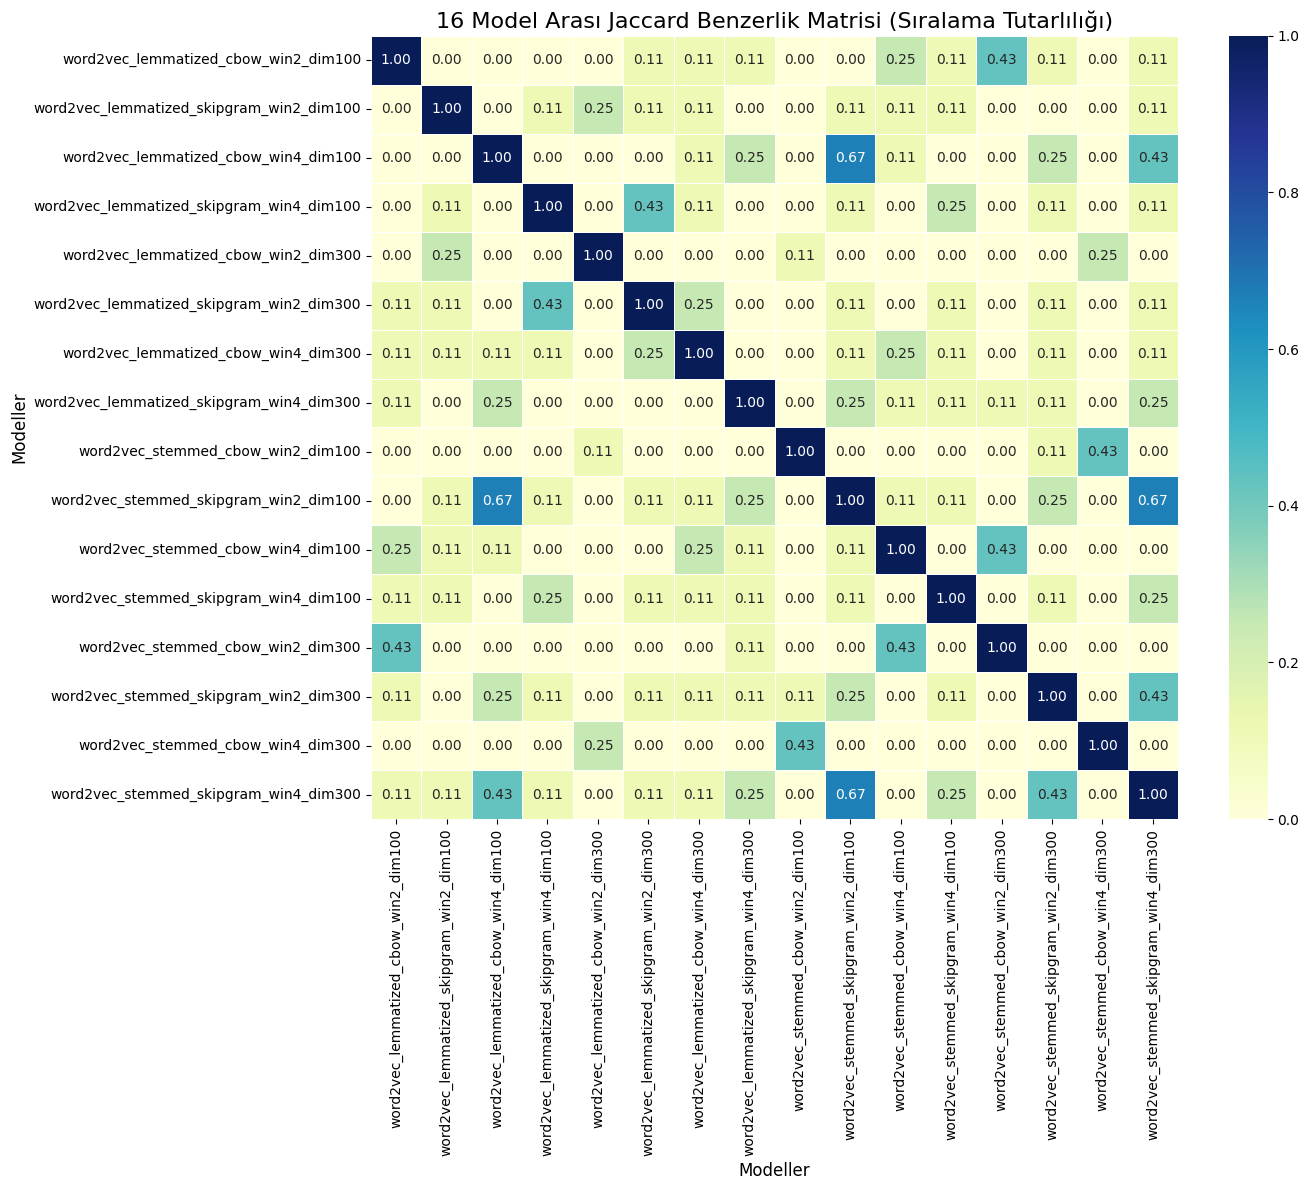

✅ Jaccard Isı Haritası 'jaccard_heatmap.png' olarak kaydedildi!


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. KOSİNÜS BENZERLİK TABLOSU OLUŞTURMA
# Bu tabloyu kopyalayıp doğrudan Word raporuna yapıştırabilirsin.
print("--- 1. KOSİNÜS DEĞERLENDİRME TABLOSU (OBJECKTİF) ---")
df_cosine = pd.DataFrame.from_dict(tum_sonuclar, orient='index')

# Sütunları daha okunabilir hale getirelim
df_tablo = pd.DataFrame({
    'Model Adı': df_cosine.index,
    '5 Benzer Metin (Doc IDs)': df_cosine['doc_ids'].apply(lambda x: ", ".join(x)),
    'Skorlar (Kosinüs)': df_cosine['skorlar'].apply(lambda x: ", ".join(map(str, x))),
    'Ortalama Skor': df_cosine['ortalama_skor']
}).reset_index(drop=True)

display(df_tablo) # Colab'de şık bir tablo olarak gösterir

# CSV olarak kaydetmek istersen (isteğe bağlı)
df_tablo.to_csv("kosinus_degerlendirme_tablosu.csv", index=False)


# 2. JACCARD BENZERLİK MATRİSİ HESAPLAMA (Sıralama Tutarlılığı)
print("\n--- 2. JACCARD BENZERLİK MATRİSİ HESAPLANIYOR ---")
modeller = list(tum_sonuclar.keys())
jaccard_matrix = pd.DataFrame(index=modeller, columns=modeller, dtype=float)

# Jaccard Formülü: Kesişim / Birleşim
def jaccard_benzerligi(liste1, liste2):
    kesisim = len(set(liste1).intersection(set(liste2)))
    birlesim = len(set(liste1).union(set(liste2)))
    return kesisim / birlesim if birlesim != 0 else 0.0

for model1 in modeller:
    for model2 in modeller:
        docs1 = tum_sonuclar[model1]['doc_ids']
        docs2 = tum_sonuclar[model2]['doc_ids']
        # Aynı modelin kendisiyle kıyası her zaman 1.00 olur
        jaccard_matrix.loc[model1, model2] = jaccard_benzerligi(docs1, docs2)


# 3. HEATMAP (ISI HARİTASI) ÇİZİMİ
plt.figure(figsize=(14, 12))
sns.heatmap(jaccard_matrix, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=.5)
plt.title("16 Model Arası Jaccard Benzerlik Matrisi (Sıralama Tutarlılığı)", fontsize=16)
plt.xlabel("Modeller", fontsize=12)
plt.ylabel("Modeller", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Grafiği rapora eklemen için bilgisayara kaydeder
plt.savefig("jaccard_heatmap.png", dpi=300)
plt.show()

print("✅ Jaccard Isı Haritası 'jaccard_heatmap.png' olarak kaydedildi!")